# Perceptrón Multicapa: Caso práctico I

## Dataset

El conjunto de datos flor Iris o conjunto de datos iris de Fisher es un
conjunto de datos multivariante introducido por Ronald Fisher en su artículo de 1936, _The use of multiple measurements in taxonomic problems_ (El uso de medidas múltiples en problemas taxonómicos) como un ejemplo de análisis discriminante lineal. A veces, se llama Iris conjunto de datos de Anderson porque Edgar Anderson coleccionó los datos para cuantificar la variación morfológica de la flor Iris de tres especies relacionadas. Dos de las tres especies se coleccionaron en la Península de la Gaspesia «todos son de la misma pastura, y recolectado el mismo día y medidos al mismo tiempo por la misma persona con el mismo aparato».

El conjunto de datos contiene 50 muestras de cada una de tres especies de Iris (Iris setosa, Iris virginica e Iris versicolor). Se midió cuatro rasgos de cada muestra: el largo y ancho del sépalo y pétalo, en centímetros. Basado en la combinación de estos cuatro rasgos, Fisher desarrolló un modelo discriminante lineal para distinguir entre una especie y otra.

## Enunciado

En este ejercicio vamos utilizar el conjunto de datos Iris para evaluar el funcionamiento del perceptrón y visualizar las capacidades que nos proporciona a la hora de clasificar diferentes categorías dentro de un conjunto de datos.

## 1. Lectura del conjunto de datos

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
iris_dataset = load_iris()

In [ ]:
iris_dataset["data"]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
dir(iris_dataset)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [ ]:
# Visualizamos las etiquetas del conjunto de datos
iris_dataset["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
import pandas as pd
import numpy as np

# Construye un df de pandas conbianndo los datos (X) y las etiquetas (y) del dataset Iris.
df = pd.DataFrame(data= np.c_[iris_dataset['data'], iris_dataset['target']],
                     columns= iris_dataset['feature_names'] + ['target'])

In [ ]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
5,5.4,3.9,1.7,0.4,0.0
6,4.6,3.4,1.4,0.3,0.0
7,5.0,3.4,1.5,0.2,0.0
8,4.4,2.9,1.4,0.2,0.0
9,4.9,3.1,1.5,0.1,0.0


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
df["target"].value_counts()

,count
target,
0.0,50
1.0,50
2.0,50


In [ ]:
df["petal width (cm)"]

,petal width (cm)
0,0.2
1,0.2
2,0.2
3,0.2
4,0.2
...,...
145,2.3
146,1.9
147,2.0
148,2.3


In [ ]:
columna_filtrada = df.loc[df["petal width (cm)"]>1]
columna_filtrada

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1.0
51,6.4,3.2,4.5,1.5,1.0
52,6.9,3.1,4.9,1.5,1.0
53,5.5,2.3,4.0,1.3,1.0
54,6.5,2.8,4.6,1.5,1.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [ ]:
columna_filtrada = df["sepal length (cm)"]
columna_filtrada

,sepal length (cm)
0,5.1
1,4.9
2,4.7
3,4.6
4,5.0
...,...
145,6.7
146,6.3
147,6.5
148,6.2


In [ ]:
columna_filtrada = df.loc[df["petal length (cm)"]>1.3, "target"]
columna_filtrada

,target
0,0.0
1,0.0
3,0.0
4,0.0
5,0.0
...,...
145,2.0
146,2.0
147,2.0
148,2.0


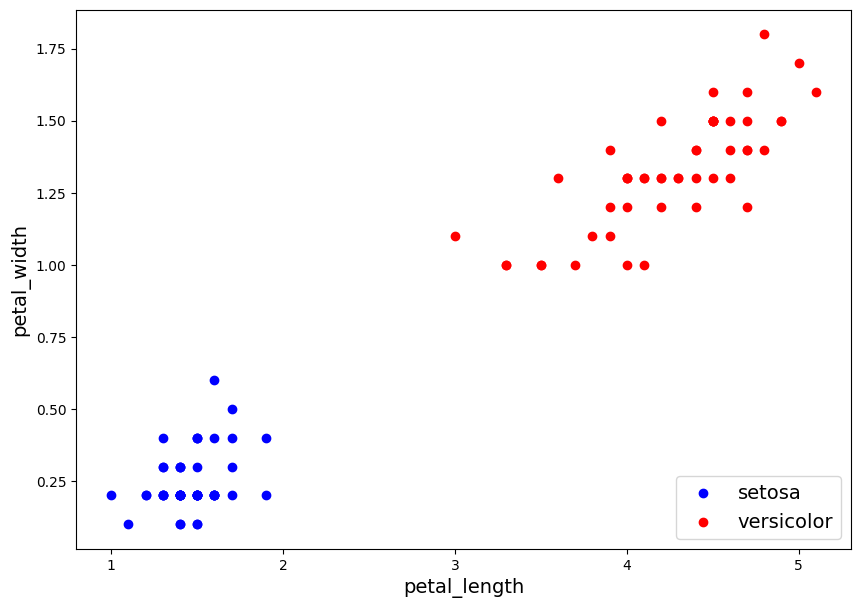

In [ ]:
# Representacion grafica de dos dimensiones del conjunto de datos
#Vamos graficar dos especies distintas (target = 0 y 1).
import matplotlib.pyplot as plt

#Me quedo con las filas
df_filas = df.loc[df["target"] == 0]
df_filas = df_filas["petal length (cm)"]


fig = plt.figure(figsize=(10, 7))

x = df_filas # solo para  0
plt.scatter(x,
            df["petal width (cm)"][df["target"] == 0], c="b", label="setosa")

plt.scatter(df["petal length (cm)"][df["target"] == 1],
            df["petal width (cm)"][df["target"] == 1], c="r", label="versicolor")

plt.xlabel("petal_length", fontsize=14)
plt.ylabel("petal_width", fontsize=14)
plt.legend(loc="lower right", fontsize=14)

plt.show()

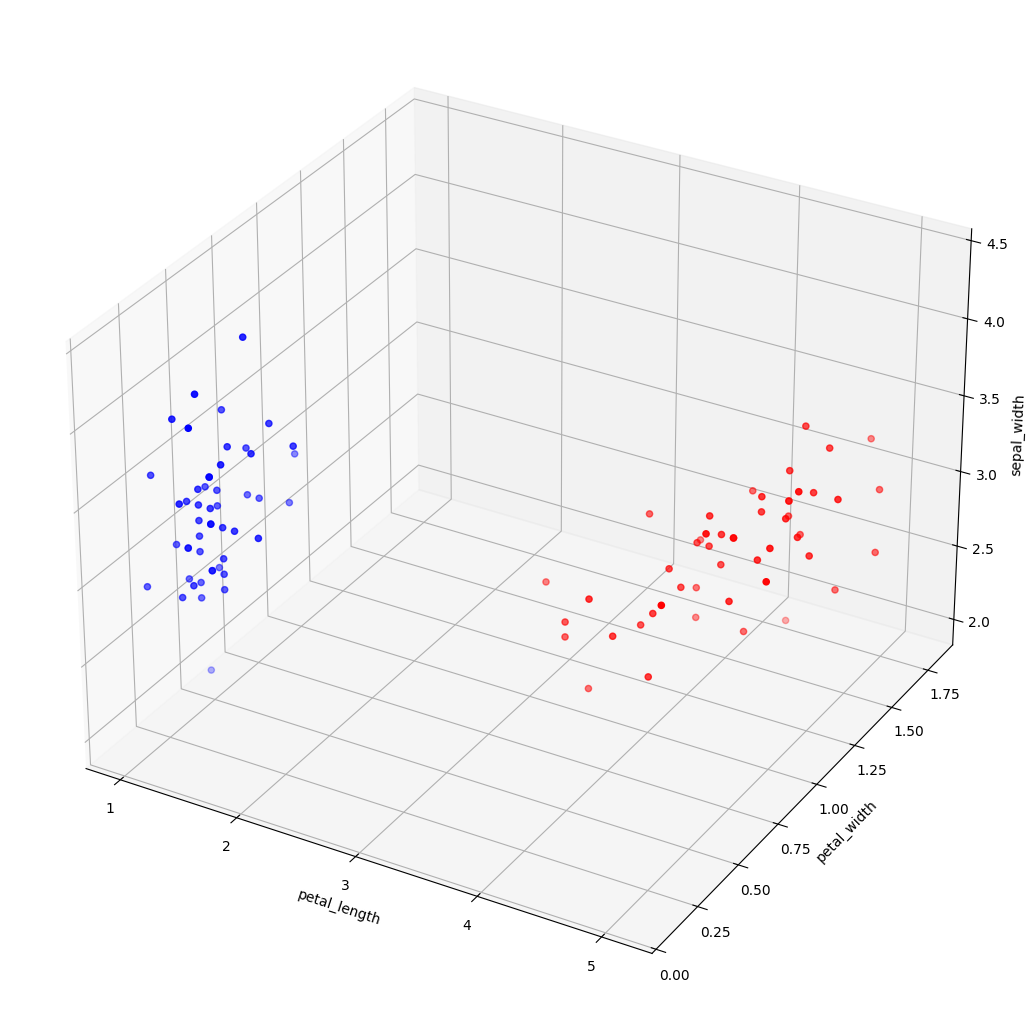

In [ ]:
# Representacion grafica de tres dimensiones del conjunto de datos
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(13, 15))
ax = plt.axes(projection="3d")

ax.scatter3D(df["petal length (cm)"][df["target"] == 0],
            df["petal width (cm)"][df["target"] == 0],
            df["sepal width (cm)"][df["target"] == 0], c="b")

ax.scatter3D(df["petal length (cm)"][df["target"] == 1],
            df["petal width (cm)"][df["target"] == 1],
            df["sepal width (cm)"][df["target"] == 1], c="r")

ax.set_xlabel("petal_length")
ax.set_ylabel("petal_width")
ax.set_zlabel("sepal_width")


plt.show()


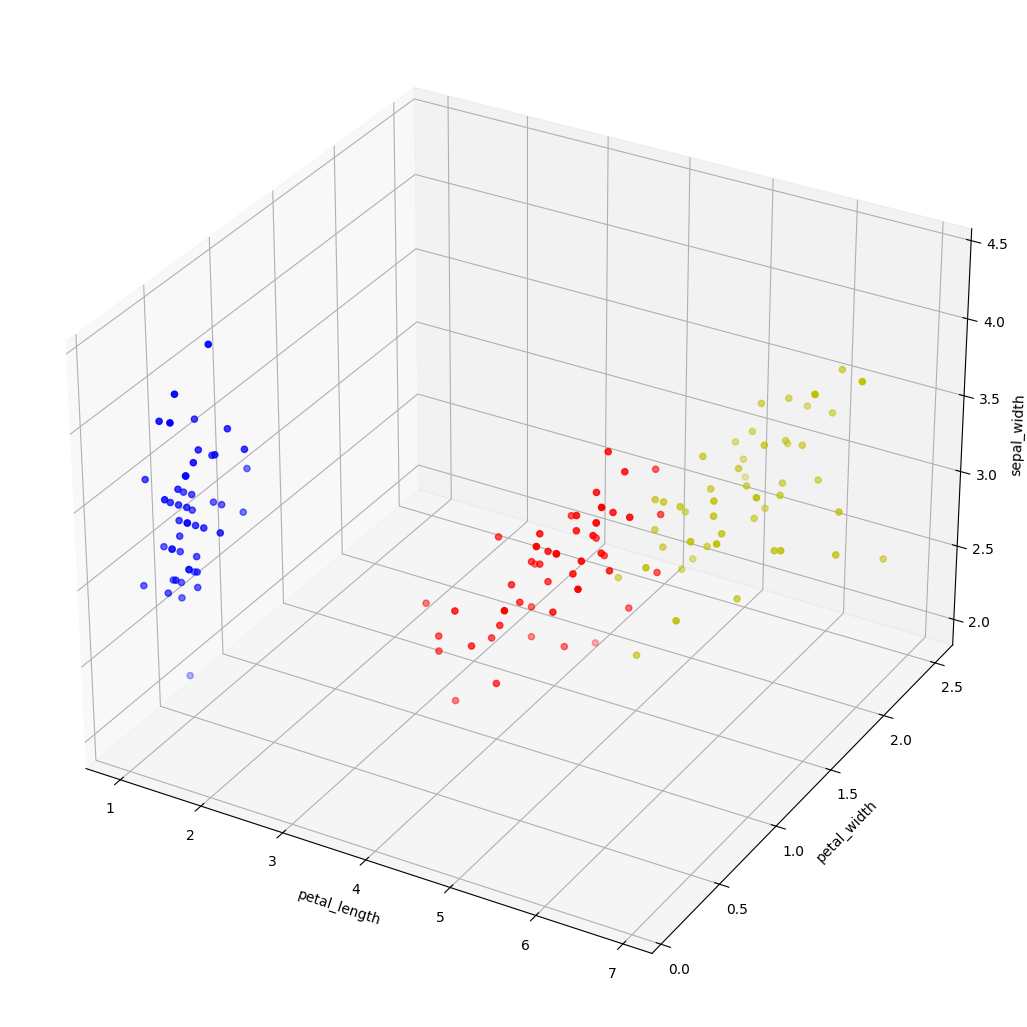

In [ ]:
# Representacion grafica de tres dimensiones del conjunto de datos
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(13, 15))
ax = plt.axes(projection="3d")

ax.scatter3D(df["petal length (cm)"][df["target"] == 0],
            df["petal width (cm)"][df["target"] == 0],
            df["sepal width (cm)"][df["target"] == 0], c="b")

ax.scatter3D(df["petal length (cm)"][df["target"] == 1],
            df["petal width (cm)"][df["target"] == 1],
            df["sepal width (cm)"][df["target"] == 1], c="r")

ax.scatter3D(df["petal length (cm)"][df["target"] == 2],
            df["petal width (cm)"][df["target"] == 2],
            df["sepal width (cm)"][df["target"] == 2], c="y")

ax.set_xlabel("petal_length")
ax.set_ylabel("petal_width")
ax.set_zlabel("sepal_width")

plt.show()

# **Situaciones donde realizamos la reducción de características**

#1. Facilitar la Visualización

El perceptrón trabaja en un espacio de características y, al reducir el número de características a dos, puedes visualizar claramente las fronteras de decisión que el modelo genera.

- Con cuatro características (las originales del conjunto Iris), no podrías graficar directamente las fronteras en un espacio visual 2D.
- Al elegir dos características relevantes (por ejemplo, largo y ancho del pétalo), puedes trazar un plano y observar cómo el perceptrón clasifica los puntos.

---



# 2. Simplicidad del Modelo

El perceptrón es un modelo de clasificación lineal, que intenta separar las clases usando un hiperplano en el espacio de características. Reducir el número de dimensiones:

Hace más fácil comprender el comportamiento del modelo.
Permite centrarse en las características que más contribuyen a la separación de las clases.
Por ejemplo, las características largo del pétalo y ancho del pétalo son más discriminativas para separar las especies de Iris que las del sépalo. Si incluyes características menos relevantes, el modelo podría necesitar más iteraciones o encontrar fronteras menos óptimas.

---

## 3. Evitar el Ruido de Características Irrelevantes**
Aunque el perceptrón puede manejar varias dimensiones, incluir características que no son útiles para distinguir entre clases (como en este caso, características del sépalo) podría:

Introducir ruido y dificultar la convergencia del modelo.
Generar una clasificación menos precisa debido a la información redundante o poco discriminativa.

---

# Por ello, trabajar con un subconjunto bien elegido de características puede mejorar el rendimiento.

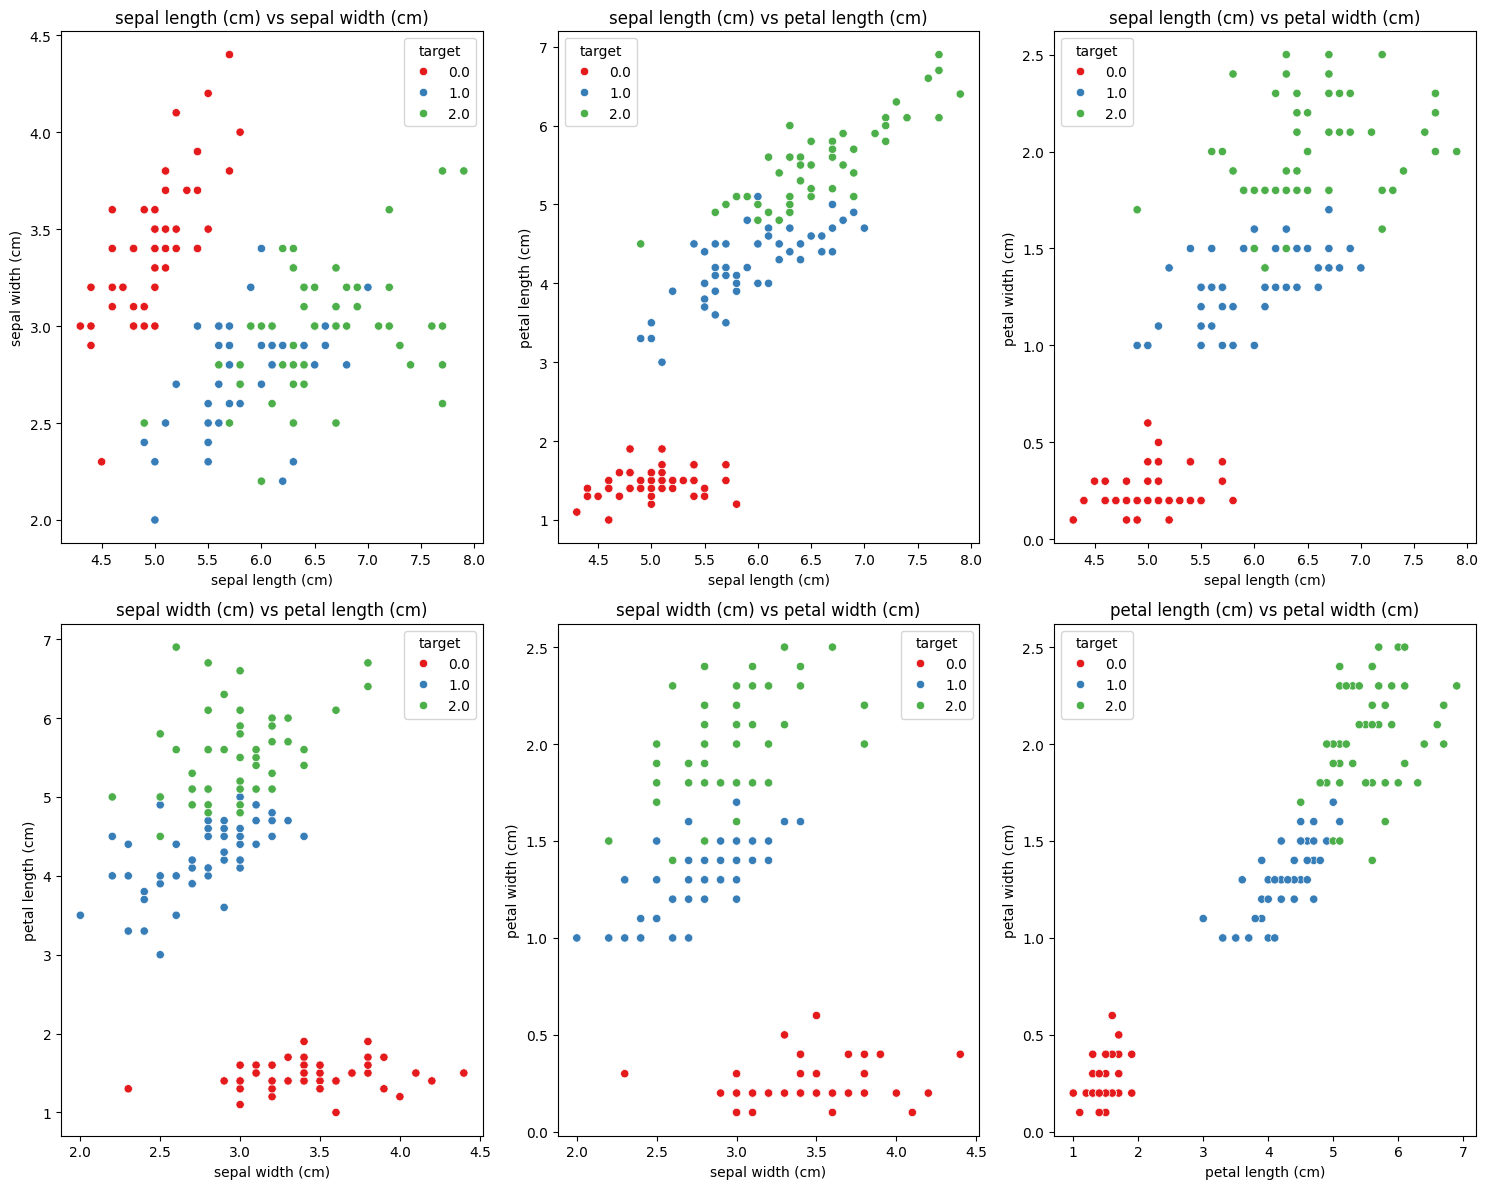

In [27]:

import seaborn as sns

# Definir las combinaciones de las características
combinaciones = [
    ("sepal length (cm)", "sepal width (cm)"),
    ("sepal length (cm)", "petal length (cm)"),
    ("sepal length (cm)", "petal width (cm)"),
    ("sepal width (cm)", "petal length (cm)"),
    ("sepal width (cm)", "petal width (cm)"),
    ("petal length (cm)", "petal width (cm)")
]

# Crear los gráficos de dispersión para todas las combinaciones
plt.figure(figsize=(15, 12))

for i, (x_col, y_col) in enumerate(combinaciones, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(
        x=x_col, y=y_col, hue="target", data=df, palette="Set1"
    )
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)

plt.tight_layout()
plt.show()


In [28]:
#NOS QUEDAMOS CON EL GRÁFICO 6 (EL GRÁFICO 5 TAMBIÉN VALDRÍA)
# Reducimos el conjunto de datos para entrenar el algoritmo y visualizar el resultado
df_prueba=df["petal length (cm)"]
df_prueba

df_reduced = df[["petal length (cm)", "petal width (cm)", "target"]]
df_reduced

,petal length (cm),petal width (cm),target
0,1.4,0.2,0.0
1,1.4,0.2,0.0
2,1.3,0.2,0.0
3,1.5,0.2,0.0
4,1.4,0.2,0.0
...,...,...,...
145,5.2,2.3,2.0
146,5.0,1.9,2.0
147,5.2,2.0,2.0
148,5.4,2.3,2.0


In [29]:
# Separamos las etiquetas de salida del resto de caracteristicas del conjunto de datos
X_df = df_reduced[["petal length (cm)", "petal width (cm)"]]
y_df = df_reduced[["target"]]

In [30]:
# Separamos las etiquetas de salida del resto de caracteristicas del conjunto de datos
X_df = df_reduced[["petal length (cm)", "petal width (cm)"]]
y_df = df_reduced[["target"]]

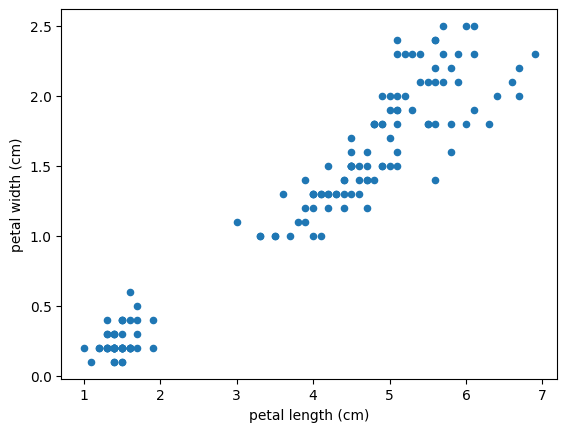

In [31]:
# Visualizamos el conjunto de datos de entrenamiento reducido
X_df.plot.scatter("petal length (cm)", "petal width (cm)")
plt.show()

## 3.1 Perceptrón Simple

En el contexto del modelo Perceptrón de sklearn, los parámetros max_iter=1000 y random_state=40 tienen el siguiente significado:

max_iter=1000:

Este parámetro establece el número máximo de iteraciones que el algoritmo de aprendizaje está dispuesto a realizar durante el proceso de entrenamiento.
En el caso del Perceptrón, durante el entrenamiento, el modelo pasa varias veces por los datos para ajustar los pesos de manera iterativa. Si no se alcanza la convergencia antes de alcanzar el número de iteraciones especificado, el entrenamiento se detiene.
En este caso, el modelo intentará ajustar los pesos hasta 1000 veces antes de detenerse, lo cual es un valor razonable para muchos problemas. Si se necesita más tiempo de entrenamiento, puedes aumentar este número.
random_state=40:

Este parámetro establece la semilla aleatoria usada para inicializar el generador de números aleatorios. La semilla asegura que los resultados sean reproducibles.
Si usas el mismo valor de random_state (en este caso, 40) en ejecuciones posteriores con los mismos datos, obtendrás exactamente los mismos resultados cada vez que ejecutes el código, ya que la aleatoriedad se controla.
Esto es útil cuando deseas asegurar que tus experimentos sean consistentes y puedas comparar resultados.

### Representacion grafica del limite de decisión

El siguiente código visualiza cómo el **Perceptrón** divide el espacio de características en diferentes regiones (límites de decisión) y muestra cómo se clasifican los puntos de datos reales (de las tres clases).



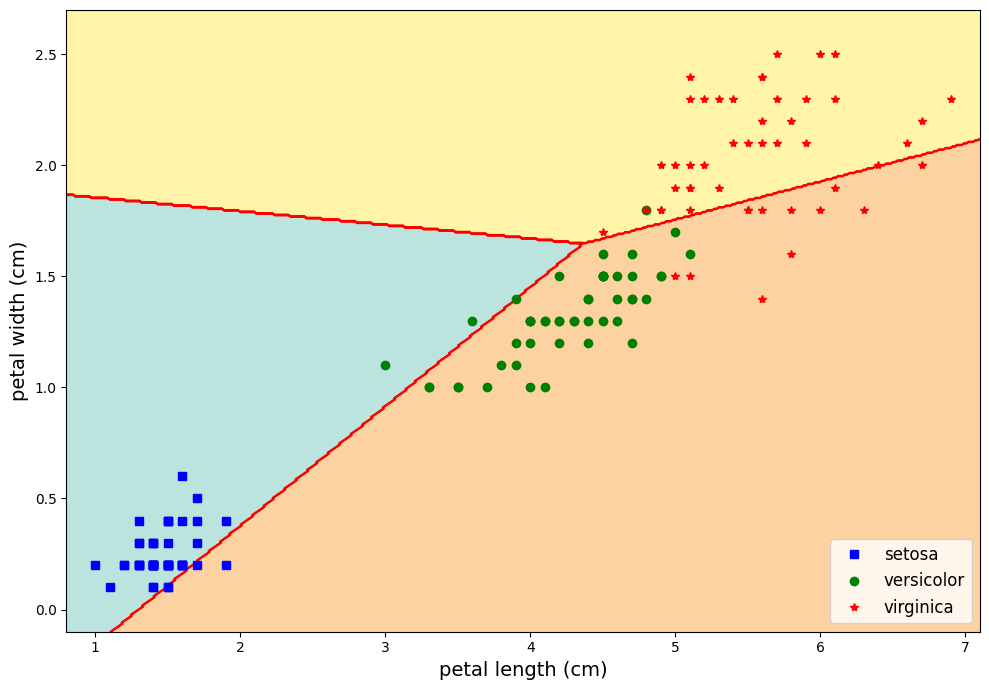

In [32]:
from sklearn.linear_model import Perceptron
import numpy as np
import matplotlib.pyplot as plt

clf = Perceptron(max_iter=1000, random_state=40)

y = y_df.values.ravel()         # no piso y_df
clf.fit(X_df.values, y)         # uso .values para evitar warning

def plot_decision_boundary(clf, X_df, y, feature_names=("petal length (cm)", "petal width (cm)")):
    X = X_df.values

    mins = X.min(axis=0) - 0.2
    maxs = X.max(axis=0) + 0.2
    x_min, y_min = mins
    x_max, y_max = maxs

    n_points = 400
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, n_points),
        np.linspace(y_min, y_max, n_points)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, cmap="Set3", alpha=0.6)
    plt.contour(xx, yy, Z, linewidths=1, colors='r')

    colors = ['b', 'g', 'r']
    markers = ['s', 'o', '*']
    labels = ['setosa', 'versicolor', 'virginica']

    for cls, color, marker, label in zip([0, 1, 2], colors, markers, labels):
        plt.plot(
            X[y == cls, 0],
            X[y == cls, 1],
            f'{color}{marker}',
            label=label
        )

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel(feature_names[0], fontsize=14)
    plt.ylabel(feature_names[1], fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_decision_boundary(clf, X_df, y)


## 3.2 Perceptrón Multicapa


=== Perceptrón Multicapa (MLP) ===
Número de capas (incluye entrada y salida): 3
Capas ocultas: (100,)
Número de salidas (clases): 3
Forma de los pesos de la segunda capa: (100, 3)
Bias de la segunda capa: [ 0.05123435 -0.07854761 -0.41859065]


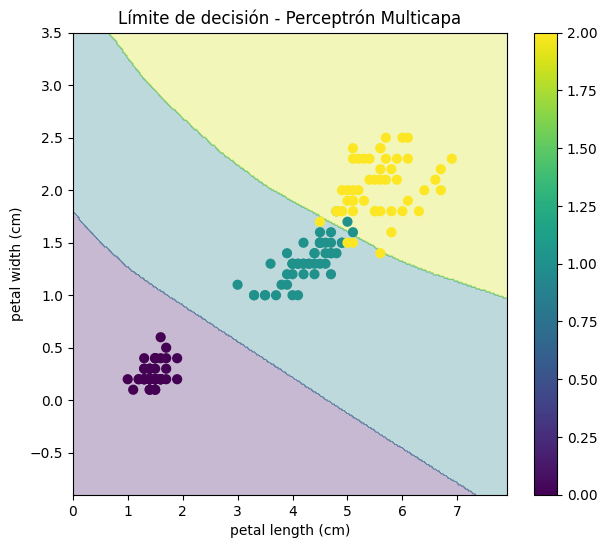

In [35]:
# ============================================
# 0. IMPORTS
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

# ============================================
# 1. CARGAR DATOS (Iris)
#    Usamos solo 2 características:
#    - petal length (cm)
#    - petal width (cm)
# ============================================

iris = load_iris()

# X: solo columnas 2 y 3 (pétalo)
X = iris["data"][:, [2, 3]]   # shape (150, 2)
y = iris["target"]            # shape (150,)

feature_names = ("petal length (cm)", "petal width (cm)")
class_labels  = iris["target_names"]  # ['setosa', 'versicolor', 'virginica']



# ============================================
# 2. PERCEPTRÓN MULTICAPA (MLPClassifier)
# ============================================

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),  # 1 capa oculta con 100 neuronas
    max_iter=1000,
    random_state=42
)
mlp.fit(X, y)

print("\n=== Perceptrón Multicapa (MLP) ===")
print("Número de capas (incluye entrada y salida):", mlp.n_layers_)
print("Capas ocultas:", mlp.hidden_layer_sizes)
print("Número de salidas (clases):", mlp.n_outputs_)
print("Forma de los pesos de la segunda capa:", mlp.coefs_[1].shape)
print("Bias de la segunda capa:", mlp.intercepts_[1])

def plot_decision_boundary(model, X, y, feature_names=None, title=None):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=40)

    if feature_names:
        plt.xlabel(feature_names[0])
        plt.ylabel(feature_names[1])

    if title:
        plt.title(title)

    plt.colorbar(scatter)
    plt.show()
plot_decision_boundary(
    mlp,
    X,
    y,
    feature_names,
    title="Límite de decisión - Perceptrón Multicapa"
)